#  Анализ пользователей и проверка гипотез сервиса проката самокатов 
Автор: Ельцова Анастасия

### Цели и задачи проекта

**Цель:** Проанализировать демографию пользователей и особенности использования самокатов, а также определить возможную выгоду от распространения платной подписки на самокаты.  

**Задачи:**
1. Провести предобработку и объединение данных
2. Исследовать демографические характеристики пользователей (возраст, география, тип подписки)
3. Проанализировать паттерны использования самокатов (длительность поездок, дистанция)
4. Рассчитать выручку от пользователей с подпиской и без
5. Провести статистическую проверку трёх ключевых гипотез бизнеса
6. Смоделировать распределения для оценки доли длительных поездок

### Описание данных

Для анализа поступили три датасета с данными о пользователях сервиса, их поездках за один год и стоимости услуг в подписках:

- Таблица с пользователями `users_go`:
    * `user_id` — уникальный идентификатор пользователя
    * `name` — имя пользователя
    * `age` — возраст
    * `city` — город
    * `subscription_type` — тип подписки: `free`, `ultra`.

- Таблица с поездками `rides_go`:
    * `user_id` — уникальный идентификатор пользователя
    * `distance` — расстояние в метрах, которое пользователь проехал в текущей сессии
    * `duration` — продолжительность сессии в минутах, то есть время с того момента, как пользователь нажал кнопку «Начать поездку», до того, как он нажал кнопку «Завершить поездку»
    * `date` — дата совершения поездки.

- Таблица с подписками `subscriptions_go`:
    * `subscription_type` — тип подписки
    * `minute_price` — стоимость одной минуты поездки по этой подписке
    * `start_ride_price` — стоимость начала поездки
    * `subscription_fee` — стоимость ежемесячного платежа

### Содержимое проекта

1. Загрузка данных
2. Знакомство с данными и их предварительная подготовка
3. Исследовательский анализ данных (EDA)
4. Объединение данных
5. Подсчёт выручки
6. Проверка гипотез
7. Распределения
8. Итоговые выводы и рекомендации

---
## 1. Загрузка данных
Загрузим все необходимые данные и познакомимся с содержанием таблиц.

---

In [1]:
# Импортируем библиотеки
import pandas as pd

#Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt

#Загружаем библиотеку для статистического анализа
import scipy.stats as st

---
Сохраним в отдельные датафреймы три CSV-файла



In [2]:
df_users_go = pd.read_csv('https://_____.csv')
df_rides_go = pd.read_csv('https://_____.csv')
df_subscriptions_go = pd.read_csv('https://_____.csv')

---
Выведем первые пять строк каждого датафрейма. Познакомимся с содержанием таблиц.

---

In [3]:
df_users_go.head()

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [4]:
df_rides_go.head()

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [5]:
df_subscriptions_go.head()

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


---
Определим количество строк в каждом из трёх датафреймов, чтобы оценить объем данных и выявить аномалии, например слишком малое количество записей.

---

In [6]:
users_rows = len(df_users_go)
rides_rows = len(df_rides_go)
subscriptions_rows = len(df_subscriptions_go)

print(f"{users_rows} {rides_rows} {subscriptions_rows}")

1565 18068 2


---
## 2. Знакомство с данными и их предварительная подготовка

Убедимся в качестве предоставленных данных, чтобы лучше понять структуру и устранить потенциальные проблемы в таблицах.

---
**Определение типов данных**

Выведем тип данных каждой колонки датафрейма `df_rides_go`, чтобы проверить корректность типов и подготовить данные для дальнейшей обработки.

---

In [7]:
df_rides_go.dtypes

user_id       int64
distance    float64
duration    float64
date         object
dtype: object

---
**Преобразование формата даты**

Приведем столбец `date` к типу даты - это упростит работу с временными данными.

---

In [8]:
df_rides_go['date'] = pd.to_datetime(df_rides_go['date'])

---
**Создание столбца с месяцем**

На основе столбца `date` создадим новый столбец `month`, содержащий номер месяца - понадобится для последующей группировки данных и анализа сезонных трендов.

---

In [9]:
df_rides_go['month']= df_rides_go['date'].dt.month

In [10]:
df_rides_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
 4   month     18068 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1)
memory usage: 635.3 KB


---
Тип данных даты успешно приведен в `datetime`, столбец с месяцем добавлен.

---
**Поиск дублей и пропусков**

Для понимания полноты и уникальности данных пользователей, определим количество пропусков и дубликатов в датафрейме пользователей `df_users_go`.

---

In [11]:
df_users_go_missing = df_users_go.isnull().sum().sum()
df_users_go_duplicate = df_users_go.duplicated().sum()

print(f'{df_users_go_missing} {df_users_go_duplicate}')

0 31


---
**Заполнение пропусков и удаление дублей**

---
Удалим дубликаты из датафрейма `df_users_go`.

---

In [12]:
df_users_go = df_users_go.drop_duplicates(subset = None, keep = 'first')

---
**Округление длительности поездки**

Так как плата взимается только за целое число минут, округлим время поездки `duration` до целого числа в датафрейме `df_rides_go` и приведем эту колонку к целочисленному типу `int`.

---

In [13]:
df_rides_go['duration']= df_rides_go['duration'].round().astype(int)

---
## 3. Исследовательский анализ данных (EDA)

Внимательно изучим и визуализируем информацию о географии и демографии сервиса, а также лучше поймем закономерности в дистанциях и длительности поездок.

---
**Количество пользователей по городам**

Изучим количество пользователей в каждом из городов, пользуясь данными из датафрейма `df_users_go`. 

Выведем на экран объект `pd.Series`, названный `users_by_city_count`, с одной колонкой `count` — суммарным количеством пользователей в каждом городе `city`, отсортированным по убыванию.

---

In [14]:
users_by_city_count = df_users_go['city'].value_counts()

users_by_city_count

city
Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: count, dtype: int64

---
**Количество пользователей подписки**

Выведем на экран серию `subscription_type_count` с количеством пользователей для каждого типа подписки `subscription_type`.

---

In [15]:
subscription_type_count = df_users_go['subscription_type'].value_counts()

subscription_type_count

subscription_type
free     835
ultra    699
Name: count, dtype: int64

---
**Круговая диаграмма**

Построим круговую диаграмму, указав процент пользователей с `free` и `ultra` подпиской.

---

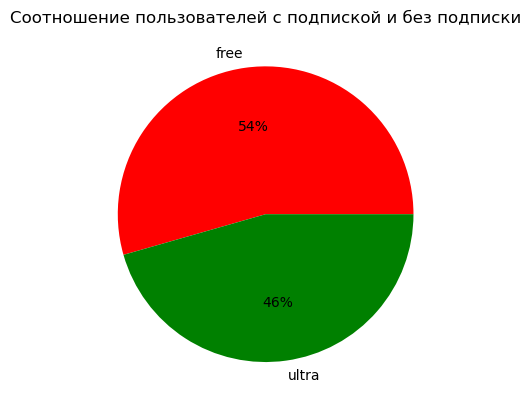

In [16]:
subscription_type_count.plot(
    kind='pie',
    title='Соотношение пользователей с подпиской и без подписки',
    autopct='%.0f%%',
    ylabel= '',
    colors=['red', 'green']
)

plt.show()

---
**Гистограмма возрастов**

Построим гистограмму возрастов `age` пользователей самокатов используя количество бинов, равное разности максимального и минимального значений возраста.

---

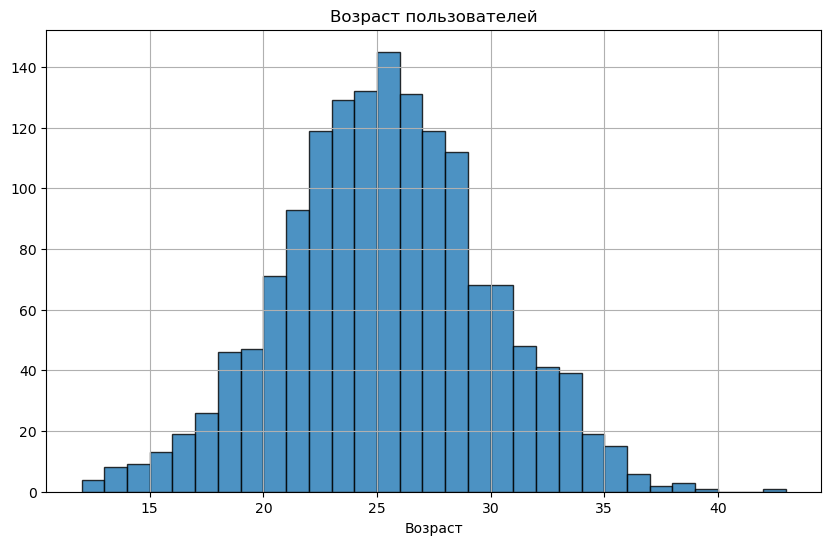

In [17]:
n_bins = df_users_go['age'].max() - df_users_go['age'].min()

df_users_go['age'].hist(figsize=(10,6), bins = n_bins, alpha = 0.8, edgecolor='black')
plt.title('Возраст пользователей')
plt.xlabel('Возраст')
plt.show()

---
**Несовершеннолетние пользователи**

Расчитаем долю несовершеннолетних (возрастом менее 18 лет) пользователей самокатов.

---

In [18]:
users_under_18 = df_users_go.loc[df_users_go['age'] < 18]

users_under_18_ratio = round((users_under_18.shape[0] / df_users_go.shape[0])*100)
print(f'Доля несовершеннолетних пользователей самокатов составляет {users_under_18_ratio}%.')

Доля несовершеннолетних пользователей самокатов составляет 5%.


---
**Характеристики длительности поездки**

С помощью описательной статистики изучим длительность поездок:

- Расчитаем среднее значение и стандартное отклонение длительности поездки
- Расчитаем 25-й и 75-й процентили длительности поездки

---

In [19]:
duration_mean = round(df_rides_go['duration'].mean())
duration_std = round(df_rides_go['duration'].std())

duration_pct25 = round(df_rides_go['duration'].quantile(0.25))
duration_pct75 = round(df_rides_go['duration'].quantile(0.75))

print(f'Средняя длительность поездки {duration_mean} минут со стандартным отклонением {duration_std}. Основная часть поездок занимает от {duration_pct25} до {duration_pct75} минут.')

Средняя длительность поездки 18 минут со стандартным отклонением 6. Основная часть поездок занимает от 14 до 22 минут.


---
## 4. Объединение данных

Объединим три таблицы в один датафрейм.

---
**Объединение таблицы пользователей и поездок**

Объединим датафреймы с информацией о пользователях `df_users_go` и поездках `df_rides_go`.

---

In [20]:
df= df_users_go.merge(df_rides_go, on='user_id', how='left')

---
**Присоединение информации о подписках**

Присоединим к полученному датафрейму `df` информацию о подписках из `df_subscriptions_go`.

---

In [21]:
df = df.merge(df_subscriptions_go, on='subscription_type', how='left')

---
**Размеры объединённого датафрейма**

Для проверки корректности объединения таблиц, выведем на экран первые пять строк датафрейма, а также количество строк и столбцов полученного датафрейма `df`. Так мы убедимся, что записи не потерялись при объединении.

---

In [22]:
# Выводим первые строки датафрейма
display(df.head)

# Выводим количество строк и столбцов в объединённом датафрейме
n_rows = df.shape[0]
n_cols = df.shape[1]
print(f'В полученном датафрейме {n_rows} строк и {n_cols} столбцов.')

<bound method NDFrame.head of        user_id     name  age       city subscription_type     distance  \
0            1     Кира   22     Тюмень             ultra  4409.919140   
1            1     Кира   22     Тюмень             ultra  2617.592153   
2            1     Кира   22     Тюмень             ultra   754.159807   
3            1     Кира   22     Тюмень             ultra  2694.783254   
4            1     Кира   22     Тюмень             ultra  4028.687306   
...        ...      ...  ...        ...               ...          ...   
18063     1534  Альберт   25  Краснодар              free  3781.098080   
18064     1534  Альберт   25  Краснодар              free  2840.423057   
18065     1534  Альберт   25  Краснодар              free  3826.185507   
18066     1534  Альберт   25  Краснодар              free  2902.308661   
18067     1534  Альберт   25  Краснодар              free  2371.711192   

       duration       date  month  minute_price  start_ride_price  \
0           

В полученном датафрейме 18068 строк и 12 столбцов.


---
**Отдельные датафреймы для пользователей с подпиской и без**

Для изучения поведения пользователей с подпиской и без, а также для проверки продуктовых гипотез, создадим два вспомогательных датафрейма на основе `df`: первый только для пользователей с подпиской `df_ultra` и второй только для пользователей без подписки `df_free`.

---

In [23]:
df_ultra = df.loc[df['subscription_type']=='ultra']
df_free = df.loc[df['subscription_type']=='free']

---
**Гистограмма длительности поездок для обоих групп**

Построим гистограмму распределения длительности поездок `duration` для пользователей с подпиской и без. Дополнительно расчитаем среднюю длительность поездки для пользователей с подпиской и без, округлив ее до целых.

---

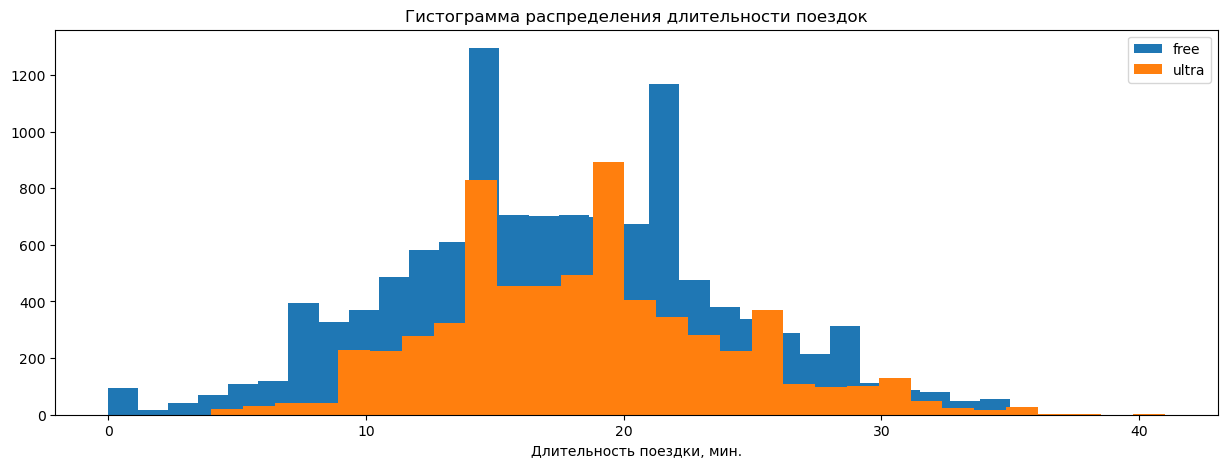

Средняя длительность поездки для пользователей без подписки 17 мин, а для пользователей с подпиской 19 мин


In [24]:
# Гистограмма длительности поездки для пользователей с подпиской и без
plt.figure(figsize=(15, 5))
plt.hist(df_free['duration'], bins=30, label='free')
plt.hist(df_ultra['duration'], bins=30, label='ultra')
plt.xlabel('Длительность поездки, мин.')
plt.title('Гистограмма распределения длительности поездок')
plt.legend()
plt.show()

# Расчет и вывод на экран средней длительности поездки для пользователей с подпиской и без
mean_duration_free = round(df_free['duration'].mean())
mean_duration_ultra = round(df_ultra['duration'].mean())
print(f'Средняя длительность поездки для пользователей без подписки {mean_duration_free} мин, а для пользователей с подпиской {mean_duration_ultra} мин')

---
## 5. Подсчёт выручки
Рассчитаем важный для бизнеса показатель — выручку.

---
**Группируем данные**

Сгруппируем данные по столбцам: `user_id`, `name`, `subscription_type`, `month`.

---

In [25]:
df_gp = df.groupby(['user_id', 'name', 'subscription_type', 'month'], as_index=False)

---
**Подсчёт агрегированных метрик**

Создадим новый датафрейм `df_agg`. В нём для каждой группы расчитаем и добавим в датафрейм следующие агрегированные значения:
- `total_distance` — сумма значений в столбце `distance`.
- `total_duration` — сумма значений в столбце `duration`.
- `rides_count` — количество элементов в столбце `duration`.
- `subscription_type` — первое значение в группе для столбца `subscription_type`.
- `minute_price` — первое значение в группе для столбца `minute_price`.
- `start_ride_price` — первое значение в группе для столбца `start_ride_price`.
- `subscription_fee` — первое значение в группе для столбца `subscription_fee`.

---

In [26]:
df_agg = df_gp.agg( # Укажите подходящий инструмент здесь
    total_distance=('distance', 'sum'),
    total_duration= ('duration', 'sum'),
    rides_count= ('duration', 'count'),
    subscription_type= ('subscription_type', 'first'),
    minute_price= ('minute_price', 'first'),
    start_ride_price= ('start_ride_price', 'first'),
    subscription_fee= ('subscription_fee', 'first')
)

---
**Функция для подсчёта выручки**

Создадим функцию `calculate_monthly_revenue(row)` для расчёта месячной выручки по формуле:

`monthly_revenue` = `start_ride_price` * `rides_count` + `minute_price` * `total_duration` + `subscription_fee`

Здесь:
- `start_ride_price * rides_count` — выручка от начала каждой поездки.
- `minute_price * total_duration` — выручка за время использования.
- `subscription_fee` — фиксированная выручка от подписок.

---

In [27]:
def calculate_monthly_revenue(row):
    monthly_revenue = (row['start_ride_price'] * row['rides_count'] + row['minute_price'] * row['total_duration'] + row['subscription_fee'])
    return monthly_revenue

---
**Создание столбца с месячной выручкой на пользователя**

Создадим новый столбец с месячной выручкой на пользователя `monthly_revenue`. Для этого применим функцию `calculate_monthly_revenue(row)` к каждой строке агрегированного датафрейма `df_agg`.

---

In [28]:
df_agg['monthly_revenue'] = df_agg.apply(calculate_monthly_revenue, axis=1)

---
**Поиск пользователя с максимальной выручкой**

Исследуем полученные значения выручки. Найдем пользователя с максимальной суммарной выручкой за весь период наблюдения и для него выведем на экран `user_id`, имя, месяц, количество поездок и выручку за каждый из месяцев.

---

In [29]:
#Считаем суммарную выручку по каждому пользователю
user_total_revenue = df_agg.groupby('user_id')['monthly_revenue'].sum()
#Сортируем по убыванию выручки
max_user_id = user_total_revenue.sort_values(ascending=False).index[0]

user_data = df_agg[df_agg['user_id'] == max_user_id]

print(user_data[['user_id', 'name', 'month', 'rides_count', 'monthly_revenue']])

      user_id       name  month  rides_count  monthly_revenue
8877     1236  Александр      1            2              228
8878     1236  Александр      2            3              614
8879     1236  Александр      3            5              762
8880     1236  Александр      4            1              202
8881     1236  Александр      5            3              574
8882     1236  Александр      6            1              282
8883     1236  Александр      7            1              290
8884     1236  Александр      8            2              452
8885     1236  Александр      9            1              122
8886     1236  Александр     10            3              430
8887     1236  Александр     11            3              494
8888     1236  Александр     12            2              476


---
## 6. Проверка гипотез

---
**Вспомогательная функция для интерпретации результатов**

Напишем вспомогательную функцию `print_stattest_results(p_value, alpha)`, которая будет интерпретировать результаты статистического теста на основе p-value и заданного уровня значимости (α-уровня). Функция должна решать, следует ли принять альтернативную гипотезу или сохранить нулевую гипотезу.

---

In [30]:
def print_stattest_results(p_value:float, alpha:float = 0.05):
    if p_value < alpha:  # Напишите код для функции здесь
        print(f"Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}. Принимаем альтернативную гипотезу.")
    else:
        print(f"Полученное значение p_value={p_value} больше критического уровня alpha={alpha}. Опровергнуть нулевую гипотезу нельзя.")

print_stattest_results(0.0001)
print_stattest_results(0.1)

Полученное значение p_value=0.0001 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Полученное значение p_value=0.1 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


---
**Длительность для пользователей с подпиской и без**

Теперь важно понять, тратят ли пользователи с подпиской больше времени на поездки.

Сформулируем нулевую и альтернативную гипотезы:
- Нулевая гипотеза (Н0): Среднее время поездки у пользователей с подпиской и без подписки одинаковое.
- Альтернативная гипотеза (Н1): Среднее время поездки у пользователей с подпиской больше, чем у пользователей без подписки.

---

In [31]:
ultra_duration = df_ultra['duration']
free_duration = df_free['duration']

results = st.ttest_ind (ultra_duration, free_duration, alternative= 'greater') # Укажите подходящий инструмент здесь
p_value = results.pvalue
print_stattest_results(p_value)
ultra_mean_duration = round(df_ultra['duration'].mean(), 2)
free_mean_duration = round(df_free['duration'].mean(), 2)

print(f'Средняя длительность поездки тарифа Ultra {ultra_mean_duration}')
print(f'Средняя длительность поездки тарифа Free {free_mean_duration}')

Полученное значение p_value=3.1600689435611813e-35 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя длительность поездки тарифа Ultra 18.55
Средняя длительность поездки тарифа Free 17.39


---
**Длительность поездки: больше или меньше критического значения**

Проанализируем ещё одну важную продуктовую гипотезу. 

Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что расстояние, которое проезжают пользователи с подпиской за одну поездку, меньше 3130 метров?

Сформулируем нулевую и альтернативную гипотезы:

- Нулевая гипотеза (Н0): Средняя дистанция поездки у пользователей с подпиской равна 3130 м.

- Альтернативная гипотеза (Н1): Средняя дистанция поездки у пользователей с подпиской больше 3130 м.

---

In [32]:
null_hypothesis = 3130
ultra_distance = df_ultra['distance']

results = st.ttest_1samp (ultra_distance, null_hypothesis, alternative = 'greater')
p_value = results.pvalue
print_stattest_results(p_value)

Полученное значение p_value=0.9195368847849785 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


---
**Прибыль от пользователей с подпиской и без**

Проверим гипотезу о том, что выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки.

Сформулируем нулевую и альтернативную гипотезы:

- Нулевая гипотеза (Н0): Средняя месячная выручка у пользователей с подпиской и без подписки одинаковая.
- Альтернативная гипотеза (Н1): Средняя месячная выручка у пользователей с подпиской выше, чем у пользователей без подписки.

In [33]:
revenue_ultra = df_agg[df_agg['subscription_type'] == 'ultra']['monthly_revenue']
revenue_free = df_agg[df_agg['subscription_type'] == 'free']['monthly_revenue']

results = st.ttest_ind(revenue_ultra, revenue_free, alternative = 'greater')
p_value = results.pvalue
print_stattest_results(p_value)

mean_revenue_ultra = round(df_agg[df_agg['subscription_type'] == 'ultra']['monthly_revenue'].mean())
mean_revenue_free = round(df_agg[df_agg['subscription_type'] == 'free']['monthly_revenue'].mean())

print(f'Средняя выручка подписчиков Ultra {mean_revenue_ultra} руб')
print(f'Средняя выручка подписчиков Free {mean_revenue_free} руб')

Полученное значение p_value=1.7274069878387966e-37 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя выручка подписчиков Ultra 359 руб
Средняя выручка подписчиков Free 322 руб


---
## 7. Распределения

В компании возникла идея предлагать дополнительную скидку подписчикам, совершающим длительные поездки продолжительностью более 30 минут. Оценим долю таких поездок.

Так как предоставленные данные охватывают лишь часть пользователей всех самокатов, а нас интересуют возможные значения для всей генеральной совокупности, смоделируем длительность поездки с помощью нормального распределения, используя в качестве параметров выборочное среднее и стандартное отклонение из доступных данных о поездках.

---
**Расчитаем выборочное среднее и стандартное отклонение**

1. Расчитаем среднюю длительность поездки и сохраним в переменную `mu`.
2. Вычислим стандартное отклонение длительности `duration` и сохраним в переменную `sigma`. Для вычисления стандартного отклонения применим метод `std()` к столбцу датасета.
3. Зададим значение переменной `target_time`, равное `30`. Эта переменная будет использоваться для последующего вычисления вероятности.
4. Выведем текстовый вывод, округлим оба значения до одного знака после точки.

---

In [34]:
# Вычисляем среднее значение
mu = df_ultra['duration'].mean()

# Вычисляем стандартное отклонение
sigma = df_ultra['duration'].std()

# Задаём целевое время
target_time = 30

# Делаем вывод
print(f'Средняя длительность поездки {round(mu, 1)}, стандартное отклонение {round(sigma)}.')

Средняя длительность поездки 18.5, стандартное отклонение 6.


---
**Вычислим значения функции распределения в точке (CDF)**

Если вычислить значение функции распределения в точке, это позволит узнать вероятность того, что случайная величина примет значение меньше заданного либо равное ему.

1. Используем функцию `norm()` из библиотеки SciPy для создания нормального распределения с параметрами `mu` и `sigma`.
2. Применим метод `cdf()` к целевому времени `target_time` для получения вероятности того, что случайная величина будет меньше этого значения или равна ему. Полученное значение сохраним в переменную `prob`, округлив до трёх знаков после точки.
3. Выведем на экран текстовый ответ.

---

In [35]:
# Вычисляем вероятность того, что случайная величина будет меньше указанного значения или равна ему

duration_norm_dist  = st.norm(mu, sigma)
prob = round(1 - duration_norm_dist.cdf(target_time),3) # Используем CDF для нахождения накопленной вероятности

print(f'Вероятность поездки более 30 минут {prob}')

Вероятность поездки более 30 минут 0.02


---
**Вероятность для интервала (CDF)**

Коллеги посчитали, что процент пользователей, для которых будет показана скидка, недостаточно большой и вряд ли поможет в увеличении лояльности клиентов. Дополнительно проверим, какой процент пользователей совершает поездки в интервале от 20 до 30 минут. Возможно, именно для них стоит провести промоакцию?

Для этого:
1. Создадим переменные `low` и `high`, указывающие на начало и конец интересующего временного интервала. В этом случае они равны 20 и 30 минут.
2. Используем кумулятивную функцию распределения (CDF) для объекта `duration_norm_dist`, чтобы вычислить вероятность достижения верхней границы (`high`) и нижней границы (`low`).
3. Вычислим вероятность попадания в интервал, округлим до трёх знаков после точки и сохраним в переменную `prob_interval`.
4. Выведем ответ, используя шаблон.

---

In [36]:
# Определяем границы интервала
low =20
high =30

# Вычисляем вероятность попадания в интервал
prob_interval = round(duration_norm_dist.cdf(high) - duration_norm_dist.cdf(low), 3)

# Выводим результат
print(f'Вероятность того, что пользователь совершит поездку длительностью от {low} до {high} минут: {prob_interval}')

Вероятность того, что пользователь совершит поездку длительностью от 20 до 30 минут: 0.377


---
**Определение критической дистанции поездок (PPF)**

Длительные поездки могут негативно сказываться на сроке службы самоката. В связи с этим принято решение установить критическую дистанцию, превышение которой будет сопровождаться дополнительной платой. Для этого определим расстояние, которое превышается только в 10% поездок (90-й процентиль).

Смоделируем распределение длительности поездок, предполагая, что оно подчиняется нормальному закону, и расчитаем критическую дистанцию, ниже которой находится 90% всех поездок.

Для этого:
1. Расчитаем среднюю дистанцию поездки для всех пользователей из датафрейма `df` (с подпиской и без) и сохраним в переменную `mu`.
2. Вычислим стандартное отклонение дистанции поездки `distance` и сохраним в переменную `sigma`.
3. Задайте значение переменной `target_prob`, равное `0.90`. Эта переменная будет использоваться для последующего вычисления критической дистанции.
4. Создадим объект нормального распределения `distance_norm` с заданными значениями `mu` и `sigma`.
5. Применим к созданному нормальному распределению `distance_norm` метод `ppf()` и в качестве аргумента передадим целевую вероятность `target_prob`. Полученное значение сохраним в переменную `critical_distance`.
6. Выведем ответ, используя шаблон.

---

In [37]:
# Вычисляем среднее значение
mu = df['distance'].mean()

# Вычисляем стандартное отклонение
sigma = df['distance'].std()

# Вероятность, для которой хотим найти значение (90% случаев)
target_prob = 0.90

# Создаём объект нормального распределения
distance_norm = st.norm(mu, sigma)

# Рассчитываем критическую дистанцию для заданного процентиля поездок
critical_distance = distance_norm.ppf(target_prob)

print(f'{100 * target_prob} % поездок имеют дистанцию ниже критического значения {critical_distance:.2f} М.')

90.0 % поездок имеют дистанцию ниже критического значения 4501.94 М.


---
## 8. Итоговые выводы и рекомендации

1. Демография и поведение:
    * Пользователи с подпиской Ultra совершают более длительные поездки (+2 мин в среднем)
    * Дистанция поездок подписчиков не превышает критический порог износа (3130 м)
3. Экономическая эффективность:
    * Подписчики приносят на 37 руб/мес больше выручки, чем пользователи без подписки
    * Разница статистически значима
5. Потенциал для акций и скидок:
    * Только 2% поездок длятся более 30 минут — скидка для таких пользователей охватит узкую аудиторию
    * 37.7% поездок попадают в интервал 20–30 минут — более перспективная целевая аудитория для промоакций
6. Рекомендации по тарифной политике:
    * Подтверждена экономическая выгода подписки — стоит продолжать стимулировать переход на Ultra
    * При введении дополнительной платы за превышение дистанции установить порог ~4500 м (90-й процентиль)